# Домашнее задание 3: Выравнивание геномов и анализ SNP

## Часть 1 - Доделываем семинар

Для начала скачаем референсный геном *E. coli* K-12 и исследуемый штамм *E. coli* O157:H7, а также файл аннотации (GenBank). Затем проведем выравнивание с помощью `MUMmer` и получим список SNP при помощи утилиты `show-snps`.

In [3]:
%%bash
mkdir -p genome_alignment_prac/{data,results}
cd genome_alignment_prac/data

curl -s -L -o ecoli_k12.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
curl -s -L -o ecoli_k12.gbff.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"
curl -s -L -o ecoli_o157.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"

gunzip -f *.gz

cd ../results

nucmer --prefix=ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12 ../data/ecoli_k12.fna ../data/ecoli_o157.fna

delta-filter -1 -i 90 ecoli_opt.delta > ecoli_filt.delta

show-snps -C -T -r ecoli_filt.delta > ecoli_snps.tsv

head -n 5 ecoli_snps.tsv

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "ecoli_opt.ntref" of length 4641653
# construct suffix tree for sequence of length 4641653
# (maximum reference length is 2305843009213693948)
# (maximum query length is 18446744073709551615)
# process 46416 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /Users/vasvadim/miniconda3/opt/mummer-3.23/mummer ecoli_opt.ntref 1.50
# reading input file "/Users/vasvadim/Downloads/bioinformatics_mipt_1sem/task_3/genome_alignment_prac/results/../data/ecoli_o157.fna" of length 5594607
# matching query-file "/Users/vasvadim/Downloads/bioinformatics_mipt_1sem/task_3/genome_alignment_prac/results/../data/ecoli_o157.fna"
# against subject-file "ecoli_opt.ntref"
# COMPLETETIME /Users/vasvadim/miniconda3/opt/mummer-3.23/mummer ecoli_opt.ntref 6.06
# SPACE /Users/vasvadim/miniconda3/opt/mummer-3.23/mummer ecoli_opt.ntref 9.90
4: FINI

/Users/vasvadim/Downloads/bioinformatics_mipt_1sem/task_3/genome_alignment_prac/results/../data/ecoli_k12.fna /Users/vasvadim/Downloads/bioinformatics_mipt_1sem/task_3/genome_alignment_prac/results/../data/ecoli_o157.fna
NUCMER

[P1]	[SUB]	[SUB]	[P2]	[BUFF]	[DIST]	[FRM]	[TAGS]
58	G	C	58	6	58	1	1	NC_000913.3	NC_002695.2


### Значение столбцов в файле SNP (вывод `show-snps -T`)
Шапка полученного файла `ecoli_snps.tsv` содержит 8 заголовков. Вот что означает каждый блок:

1. **[P1]** — Позиция мутации в референсном геноме (K-12).
2. **[SUB]** — Исходный нуклеотид в референсном геноме.
3. **[SUB]** — Измененный нуклеотид в исследуемом геноме (O157:H7).
4. **[P2]** — Позиция мутации в исследуемом геноме.
5. **[BUFF]** — Расстояние от данного SNP до ближайшего несовпадения (или конца выравнивания).
6. **[DIST]** — Расстояние от SNP до ближайшего конца последовательности.
7. **[FRM]** — Содержит две числовые колонки: рамка считывания в референсе и рамка считывания в запросе (`1  1`).
8. **[TAGS]** — Содержит две текстовые колонки: ID референсной последовательности (`NC_000913.3`) и ID исследуемой последовательности (`NC_002695.2`).

## Часть 2 - Аннотация SNP

Напишем Python-скрипт, который загружает GenBank-файл и список SNP, определяет, в какой ген попадает мутация, и анализирует её последствия (синонимичная или несинонимичная), формируя предсказанное изменение аминокислоты.

In [4]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

gb_file = "genome_alignment_prac/data/ecoli_k12.gbff"
record = SeqIO.read(gb_file, "genbank")
genome_seq = record.seq

cds_features = [f for f in record.features if f.type == "CDS"]

snp_file = "genome_alignment_prac/results/ecoli_snps.tsv"

snps_df = pd.read_csv(snp_file, sep='\t', skiprows=4, header=None)

snps_df.columns = ['P1', 'REF', 'ALT', 'P2', 'BUFF', 'DIST', 'FRM_R', 'FRM_Q', 'TAG_R', 'TAG_Q']

annotations = []

for _, row in snps_df.iterrows():
    pos = int(row['P1'])
    ref_base = str(row['REF']).upper()
    alt_base = str(row['ALT']).upper()
    
    if ref_base == '.' or alt_base == '.':
        continue

    gene_name = "Intergenic"
    product = "None"
    snp_type = "Intergenic"
    aa_change = "-"
    
    target_pos = pos - 1
    
    for f in cds_features:
        if target_pos in f:
            gene_name = f.qualifiers.get('gene', f.qualifiers.get('locus_tag',['Unknown']))[0]
            product = f.qualifiers.get('product', ['Unknown'])[0]
            
            strand = f.location.strand
            seq_start = f.location.start
            seq_end = f.location.end
            
            if strand == 1:
                offset = target_pos - seq_start
                codon_idx = offset // 3
                pos_in_codon = offset % 3
                codon_start = seq_start + codon_idx * 3
                ref_codon = genome_seq[codon_start : codon_start+3]
                
                alt_codon_list = list(ref_codon)
                alt_codon_list[pos_in_codon] = alt_base
                alt_codon = Seq("".join(alt_codon_list))
                
            else:
                offset = (seq_end - 1) - target_pos
                codon_idx = offset // 3
                pos_in_codon = offset % 3
                codon_start = seq_end - (codon_idx + 1) * 3
                ref_codon = genome_seq[codon_start : codon_start+3].reverse_complement()
                
                alt_codon_list = list(ref_codon)
                alt_codon_list[pos_in_codon] = str(Seq(alt_base).complement())
                alt_codon = Seq("".join(alt_codon_list))

            try:
                ref_aa = ref_codon.translate()
                alt_aa = alt_codon.translate()
                
                if ref_aa == alt_aa:
                    snp_type = "Synonymous"
                else:
                    snp_type = "Non-synonymous"
                
                aa_pos = codon_idx + 1
                aa_change = f"p.{ref_aa}{aa_pos}{alt_aa}"
            except Exception:
                snp_type = "Translation Error"
            
            break
            
    annotations.append({
        'Position': pos,
        'Ref': ref_base,
        'Alt': alt_base,
        'Gene': gene_name,
        'Product': product,
        'Type': snp_type,
        'AA_Change': aa_change
    })

anno_df = pd.DataFrame(annotations)
print("Аннотация завершена. Всего SNP обработано:", len(anno_df))
display(anno_df.head(10))

Аннотация завершена. Всего SNP обработано: 68945


,Position,Ref,Alt,Gene,Product,Type,AA_Change
0,58,G,C,Intergenic,None,Intergenic,-
1,64,T,C,Intergenic,None,Intergenic,-
2,393,T,G,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.R19R
3,559,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.L75L
4,588,G,A,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.G84G
5,621,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.D95D
6,669,G,A,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.L111L
7,690,C,T,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.I118I
8,774,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.T146T
9,828,C,T,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.T164T


### Визуализация результатов (График плотности и диаграмма типов)
Построим график плотности SNP (гистограмму) вдоль генома с отметками на оси x, показывающими расположение генов (Intergenic vs Genes). Также отобразим распределение типов мутаций.

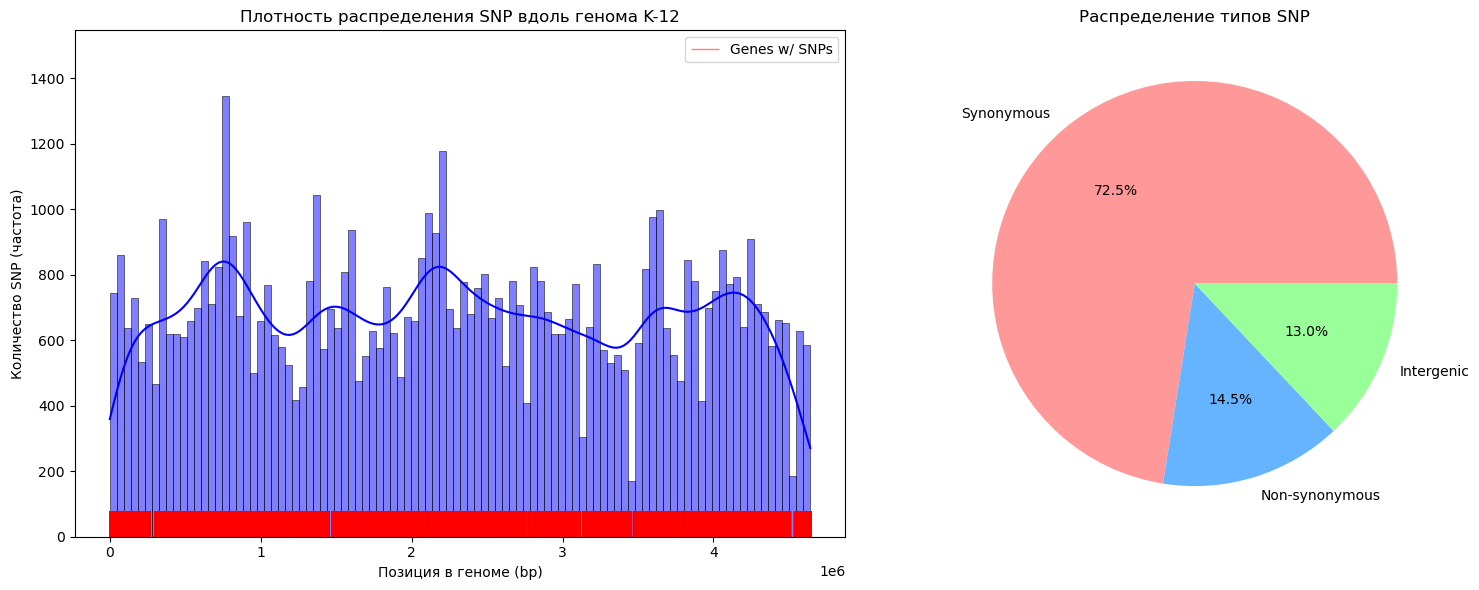

=== Топ-10 генов с наибольшим количеством SNP ===


,Ген,Количество SNP
0,ybgQ,430
1,yeeJ,250
2,ybgO,218
3,yehI,191
4,ybgP,165
5,ydbA,164
6,yfaL,139
7,yjgL,139
8,entF,131
9,evgS,109


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(anno_df['Position'], bins=100, kde=True, color='blue', ax=axes[0])

gene_positions = anno_df[anno_df['Gene'] != 'Intergenic']['Position']
sns.rugplot(gene_positions, height=0.05, color='red', ax=axes[0], alpha=0.5, label='Genes w/ SNPs')
axes[0].set_title('Плотность распределения SNP вдоль генома K-12')
axes[0].set_xlabel('Позиция в геноме (bp)')
axes[0].set_ylabel('Количество SNP (частота)')
axes[0].legend()

type_counts = anno_df['Type'].value_counts()
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[1].set_title('Распределение типов SNP')

plt.tight_layout()
plt.show()

print("=== Топ-10 генов с наибольшим количеством SNP ===")
top10_genes = anno_df[anno_df['Gene'] != 'Intergenic']['Gene'].value_counts().head(10).reset_index()
top10_genes.columns = ['Ген', 'Количество SNP']
display(top10_genes)

## Часть 3 — Поиск функционально значимых SNP

**Выбранная тема: Идентификация мутаций в генах устойчивости к антибиотикам.**

Для проведения функционального анализа отфильтруем полученную базу мутаций. Поиск будет разделен на два этапа:
1. **Проверка целевых генов из научной литературы.** Проверим локусы `marR`, `gyrA`, `hisD` и `parC`, изменения в которых часто описываются в статьях как маркеры устойчивости к антибиотикам (в частности, к фторхинолонам и хлорамфениколу).
2. **Поиск новых несинонимичных мутаций.** Отберем гены, продукты которых связаны с резистентностью (эффлюксные помпы, бета-лактамазы и т.д.). Особый интерес представляют именно несинонимичные замены, так как они меняют аминокислотную последовательность и могут напрямую влиять на конформацию белков, защищающих бактерию от лекарств.

In [ ]:
antibiotic_keywords =['resistance', 'antibiotic', 'efflux', 'lactamase', 'tetracycline', 'multidrug', 'chloramphenicol', 'pump', 'quinolone']

target_genes = ['marR', 'gyrA', 'hisD', 'parC']

targeted_findings = anno_df[anno_df['Gene'].isin(target_genes)]

ar_genes_df = anno_df[
    (anno_df['Type'] == 'Non-synonymous') & 
    (anno_df['Product'].str.contains('|'.join(antibiotic_keywords), case=False, na=False)) &
    (~anno_df['Gene'].isin(target_genes))
]

print("=== 1. Мутации в целевых генах из статей (marR, gyrA, hisD, parC) ===")
display(targeted_findings[['Position', 'Gene', 'Ref', 'Alt', 'Type', 'AA_Change']])

print(f"\n=== 2. Другие несинонимичные мутации в генах AR (найдено {len(ar_genes_df)}) ===")
display(ar_genes_df[['Position', 'Gene', 'Product', 'Type', 'AA_Change']].head(10))

=== 1. Мутации в целевых генах из статей (marR, gyrA, hisD, parC) ===


,Position,Gene,Ref,Alt,Type,AA_Change
24850,1619200,marR,C,T,Synonymous,p.R27R
24851,1619305,marR,G,A,Synonymous,p.K62K
24852,1619308,marR,A,G,Synonymous,p.V63V
24853,1619371,marR,G,A,Synonymous,p.V84V
24854,1619395,marR,C,T,Synonymous,p.D92D
...,...,...,...,...,...,...
48018,3164936,parC,G,A,Synonymous,p.I346I
48019,3164996,parC,A,G,Synonymous,p.R326R
48020,3165086,parC,G,A,Synonymous,p.R296R
48021,3165568,parC,G,A,Synonymous,p.L136L



=== 2. Другие несинонимичные мутации в генах AR (найдено 172) ===


,Position,Gene,Product,Type,AA_Change
7043,481276,acrB,multidrug efflux pump RND permease AcrB,Non-synonymous,p.S1043N
7069,484019,acrB,multidrug efflux pump RND permease AcrB,Non-synonymous,p.V129I
7282,504678,fsr,fosmidomycin efflux pump,Non-synonymous,p.P7T
8196,568576,emrE,multidrug/betaine/choline efflux transporter EmrE,Non-synonymous,p.I88V
8197,568612,emrE,multidrug/betaine/choline efflux transporter EmrE,Non-synonymous,p.I100V
14988,919649,macA,ABC-type tripartite efflux pump membrane fusio...,Non-synonymous,p.K139Q
14990,919662,macA,ABC-type tripartite efflux pump membrane fusio...,Non-synonymous,p.Q143L
14991,919898,macA,ABC-type tripartite efflux pump membrane fusio...,Non-synonymous,p.A222T
14994,920429,macB,ABC-type tripartite efflux pump ATP binding/me...,Non-synonymous,p.S28T
15007,921046,macB,ABC-type tripartite efflux pump ATP binding/me...,Non-synonymous,p.T234A


### Анализ результатов и биологический смысл

Сравнение геномов клинически опасного штамма *E. coli* O157:H7 и лабораторного K-12 выявило интересную и нестандартную стратегию адаптации патогена:

**1. «Тихие» мутации в генах-мишенях**
В статье *«Two synonymous single-nucleotide polymorphisms promoting fluoroquinolone resistance...»* [1] описывается, что устойчивость не всегда достигается изменением структуры белка-мишени. Иногда именно синонимичные мутации влияют на стабильность мРНК или скорость трансляции, повышая резистентность.
* **Наши результаты:** В первой таблице видно, что алгоритм нашел 108 мутаций в ключевых локусах (`marR` — регулятор резистентности, `parC` — мишень фторхинолонов). Однако **все эти мутации оказались синонимичными** (например, `p.R27R` в `marR`, `p.I346I` в `parC`). Структура самих белков не изменилась.
* **Вывод:** Штамм O157:H7 не стал менять мишени действия антибиотиков структурно. Накопление синонимичных замен, вероятно, является фоновой оптимизацией кодонов, а реальную множественную устойчивость бактерия обеспечивает совершенно другим путем (см. пункт 2).

**2. Тотальная перестройка эффлюксных помп**
В статье *«Supershed Escherichia coli O157:H7 Has Potential for Increased Persistence and Antibiotic Resistance»* [2] подчеркивается высокий потенциал множественной лекарственной устойчивости (MDR) у данного штамма.
* **Наши результаты:** Во второй таблице зафиксировано **172 несинонимичные замены** в других генах устойчивости. Подавляющее большинство из них сконцентрировано в генах **мультилекарственных эффлюксных помп (efflux pumps)**: `acrB` (замены p.S1043N, p.V129I), мембранном комплексе `macA/macB`, а также переносчиках `emrE` и `fsr`. 
* **Вывод:** Результаты скрипта идеально раскрывают механизм адаптации штамма. Вместо точечных мутаций в мишенях, бактерия накопила массивные изменения в мембранных каналах (помпах). Замены аминокислот меняют конформацию этих белков, позволяя клетке более эффективно «выкачивать» наружу широчайший спектр антибиотиков — от макролидов до тех же фторхинолонов.

### Применение анализа в реальной жизни (Клиническая практика)
Подобный биоинформатический пайплайн имеет колоссальное практическое значение. Если в стационар поступает пациент с тяжелой инфекцией, традиционный бактериальный посев на чувствительность к антибиотикам займет 48–72 часа. Проведя быстрое секвенирование генома патогена и выравнивание (как в нашем ноутбуке), врач за пару часов увидит отсутствие структурных мутаций в `parC`, но обнаружит массивные несинонимичные изменения в помпе `acrB`. 

Опираясь на эти данные, специалист мгновенно поймет, что перед ним MDR-штамм с мощным эффлюксом. Это позволит не тратить драгоценное время на стандартные препараты, которые бактерия просто «выплюнет», а сразу назначить антибиотики резерва или специфические ингибиторы эффлюксных помп, спасая жизнь пациенту.

---
**Используемая литература:**
1. Zhong T, et al. *Two synonymous single-nucleotide polymorphisms promoting fluoroquinolone resistance of Escherichia coli in the environment*. J Hazard Mater. 2024.
2. Mir RA, et al. *Supershed Escherichia coli O157:H7 Has Potential for Increased Persistence... and Antibiotic Resistance*. Int J Microbiol. 2020.
3. Carone BR, et al. *High incidence of multiple antibiotic resistant cells in cultures of enterohemorrhagic E. coli O157:H7*. Mutat Res. 2014. [PMID: 24361397]